In [88]:
import matplotlib.pyplot as plt

from rgfn import ReactionDataFactory
from rgfn.gfns.reaction_gfn.proxies.path_cost_proxy import PathCostProxy
from notebooks.utils.sampling_results import SamplingResult
from collections import defaultdict
from pathlib import Path

import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from notebooks.utils.training_results import TrainingResults

template_name = 'synflow_64'
task_name = 'gsk'
data_dir = Path('../../data')
threshold = 7.2 if task_name == 'seh' else 0.0


def get_path_cost_proxy(templates_name: str, sanitized: bool) -> PathCostProxy:
    if 'synflow' in templates_name:
        k = int(templates_name.split('_')[-1])
        return PathCostProxy(
            data_factory=ReactionDataFactory(
                reaction_path=data_dir / f'synflow/templates.txt',
                fragment_path=data_dir / f'synflow/fragment_{k}k.txt',
                cost_path=data_dir / f'synflow/fragment_{k}k_to_real_cost_sanitized.json' if sanitized else data_dir / f'synflow/fragment_{k}k_to_real_cost.json',
            ),
            yield_value=0.75
        )
    elif templates_name == 'rgfn_new_filtered':
        return PathCostProxy(data_factory=ReactionDataFactory(
            reaction_path=data_dir / f'rgfn_new_filtered/templates.txt',
            fragment_path=data_dir / f'rgfn_new_filtered/fragments.txt',
            cost_path=data_dir / f'rgfn_new_filtered/fragment_to_real_cost_sanitized.json' if sanitized else data_dir / f'rgfn_new_filtered/fragment_to_real_cost.json',
            yield_path=data_dir / f'rgfn_new_filtered/templates_yields.csv',
        ))
    else:
        raise ValueError(f"Unknown templates_name: {templates_name}")

path_cost_proxy = get_path_cost_proxy(template_name, sanitized=False)
sanitized_path_cost_proxy = get_path_cost_proxy(template_name, sanitized=True)

Using 64000 fragments, 105 reactions, and 197 anchored reactions
Cost mean and variance (165.35871676652314, 141.97387057883336)
Cost max 999.2437529950079
Using 64000 fragments, 105 reactions, and 197 anchored reactions
Cost mean and variance (165.4397748146447, 141.61053237141817)
Cost max 999.2437529950079


In [89]:
import numpy as np
from rdkit.Chem import MolFromSmiles, AllChem
from rdkit import DataStructs, Chem


def _get_fp(smiles: str, fp_type: str):
    if 'morgan' in fp_type:
        radius = int(fp_type[-1])
        return AllChem.GetMorganFingerprintAsBitVect(
            MolFromSmiles(smiles), radius=radius, nBits=2048, useFeatures=False, useChirality=False
        )
    else:
        return Chem.RDKFingerprint(MolFromSmiles(smiles))

def get_costs(result: SamplingResult, indices):
    actual_path_cost_proxy = sanitized_path_cost_proxy if 'synflow' in result.model_name else path_cost_proxy

    costs = []
    paths = [result.paths[i] for i in indices]
    for path in tqdm(paths, desc='path_costs'):
        current_molecule = path[0]
        current_cost = actual_path_cost_proxy.get_fragment_cost(current_molecule)
        reaction = None
        input_molecules = None
        fragment_costs = None
        counter = 0
        for molecule_or_reaction in path[1:]:
            if isinstance(molecule_or_reaction, str):
                yield_value = actual_path_cost_proxy.compute_yield_raw(input_smiles_list=input_molecules,
                                                                       output_smiles=molecule_or_reaction,
                                                                       reaction=reaction)
                current_cost = fragment_costs * yield_value ** -1
                current_molecule = molecule_or_reaction
                counter += 1
            else:
                reaction = molecule_or_reaction[0]
                fragments_smiles = [m for m in molecule_or_reaction[1:] if isinstance(m, str)]
                input_molecules = [current_molecule] + fragments_smiles
                fragment_costs = current_cost + sum(
                    actual_path_cost_proxy.get_fragment_cost(m) for m in fragments_smiles)
        costs.append(current_cost)

    return costs

def get_tanimoto_similarity(result: SamplingResult, indices):
    all_ecfp_list = [_get_fp(mol, 'morgan_3') for mol in result.molecules]
    all_ecfp_list = [all_ecfp_list[i] for i in indices]
    tanimoto_similarities = []
    for i in tqdm(range(len(all_ecfp_list)), desc='tanimoto_similarities'):
        similarities = DataStructs.BulkTanimotoSimilarity(all_ecfp_list[i], all_ecfp_list[:i] + all_ecfp_list[i + 1:])
        tanimoto_similarities.extend(similarities)
    return tanimoto_similarities

name_map = {
    'rgfn_old': 'RGFN',
    'synflownet': 'SynFlowNet',
    'rgfn_is_decomposable': 'FruGFN \n(dec.)',
    'rgfn_cost_biasing': 'FruGFN \n(cost.)',
    'rgfn_expl_bias': 'FruGFN \n(cost. expl.)',
}
model_names = ['rgfn_old', 'synflownet', 'rgfn_is_decomposable', 'rgfn_cost_biasing', 'rgfn_expl_bias']

dfs = []
dfs_sim = []
dfs_cost = []
for model_name in tqdm(model_names):
    result = SamplingResult(
        model_name=model_name,
        templates_name=template_name,
        seed=0,
        task_name=task_name,
        threshold=0.0,
        results_dir=Path('../results'),
    )
    high_reward_indices = np.array([i for i, r in enumerate(result.rewards) if r > threshold], dtype=int)
    df = pd.DataFrame(
        {
            'rewards': result.rewards,
        }
    )
    df_cost = pd.DataFrame(
        {
            'costs': get_costs(result, high_reward_indices),
        }
    )
    df_sim = pd.DataFrame(
        {
            'similarities': get_tanimoto_similarity(result, high_reward_indices),
        }
    )
    df['model_name'] = name_map[model_name]
    df_sim['model_name'] = name_map[model_name]
    df_cost['model_name'] = name_map[model_name]
    dfs.append(df)
    dfs_sim.append(df_sim)
    dfs_cost.append(df_cost)
df = pd.concat(dfs)
df_sim = pd.concat(dfs_sim)
df_cost = pd.concat(dfs_cost)

  0%|          | 0/5 [00:00<?, ?it/s]

path_costs:   0%|          | 0/1000 [00:00<?, ?it/s]

tanimoto_similarities:   0%|          | 0/1000 [00:00<?, ?it/s]

path_costs:   0%|          | 0/999 [00:00<?, ?it/s]

tanimoto_similarities:   0%|          | 0/999 [00:00<?, ?it/s]

...

tanimoto_similarities:   0%|          | 0/999 [00:00<?, ?it/s]

path_costs:   0%|          | 0/1000 [00:00<?, ?it/s]

tanimoto_similarities:   0%|          | 0/1000 [00:00<?, ?it/s]

path_costs:   0%|          | 0/998 [00:00<?, ?it/s]

tanimoto_similarities:   0%|          | 0/998 [00:00<?, ?it/s]

/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_31931/1416063445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df["model_name"], y=df["rewards"], inner='box', palette='muted')
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_31931/1416063445.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df_sim["model_name"],  y=1 - df_sim['similarities'], inner='box', palette='muted')
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_31931/1416063445.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(

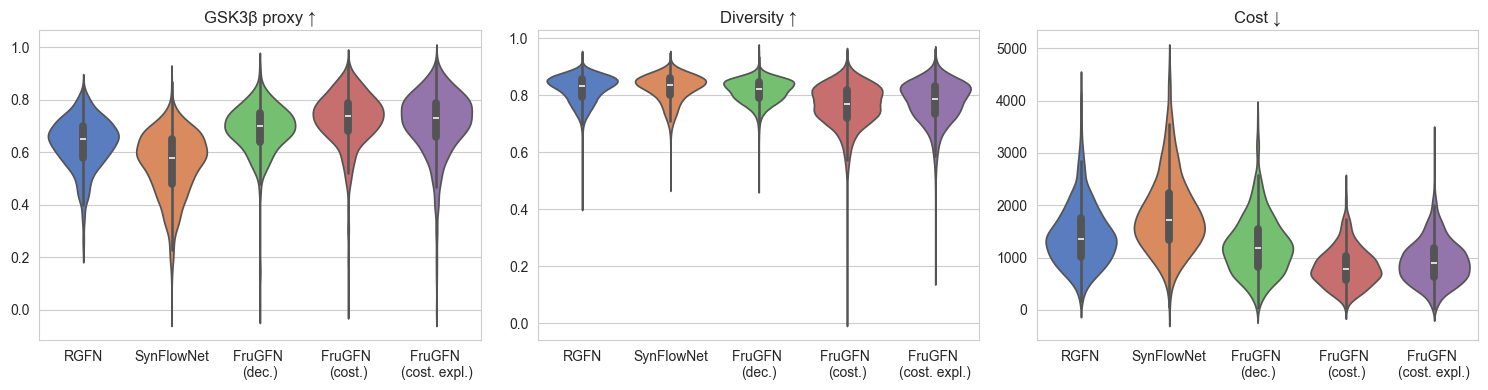

In [93]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.violinplot(x=df["model_name"], y=df["rewards"], inner='box', palette='muted')
plt.xlabel('')
plt.ylabel('')
if task_name == 'seh':
    plt.title(u'sEH proxy \u2191')
elif task_name == 'gsk':
    plt.title(u'GSK3\u03B2 proxy \u2191')
else:
    plt.title(u'JNK3 proxy \u2191')

plt.subplot(1, 3, 2)
sns.violinplot(x=df_sim["model_name"],  y=1 - df_sim['similarities'], inner='box', palette='muted')
plt.xlabel('')
plt.ylabel('')
if threshold > 0:
    plt.title(u'Diversity of high-rewarded \u2191')
else:
    plt.title(u'Diversity \u2191')

plt.subplot(1, 3, 3)
sns.violinplot(x=df_cost["model_name"],  y=df_cost['costs'], inner='box', palette='muted')
# plt.ylim(-20, 100)
plt.xlabel('')
plt.ylabel('')
if threshold > 0:   
    plt.title(u'Cost of high-rewarded \u2193')
else:
    plt.title(u'Cost \u2193')
plt.tight_layout()
plt.savefig(f'outputs/cost_plots_{task_name}_{template_name}_{threshold}.pdf')
# plt.title(u'sEH proxy \u2193')